# Controlled Comparison of Deep Ensembles and ACCRUE

This notebook compares Deep Ensembles and ACCRUE under controlled conditions.
Both methods receive exactly the same generated observations, train/validation
split, preprocessing, evaluation grid, and metric implementations.

Two synthetic regression experiments are included:

1. **Cubic:** \(y=x^3+\epsilon,\ \epsilon\sim\mathcal{N}(0,3^2)\).
2. **ACCRUE G:** \(\mu(x)=2\sin(2\pi x)\),
   \(\sigma(x)=0.5x+0.5\), and
   \(y\sim\mathcal{N}(\mu(x),\sigma(x)^2)\).

The comparison reports accuracy, probabilistic quality, calibration,
sharpness, out-of-distribution behaviour, and computational cost. Deep
Ensembles additionally provide an aleatoric/epistemic decomposition. ACCRUE
provides one residual-based uncertainty estimate and does not separately
identify epistemic uncertainty.



## Experimental design

- Five paired repetitions use seeds 42–46.
- Each repetition creates one dataset and passes the identical arrays to both
  methods.
- Normalisation statistics are fitted on the training subset only.
- Deep Ensembles use five independently initialised probabilistic networks.
- ACCRUE uses one deterministic mean network followed by one uncertainty
  network trained with the ACCRUE CRPS–reliability objective.
- Metrics are calculated separately in-distribution (ID),
  out-of-distribution (OOD), and over the full evaluation range.
- Mean RMSE is measured against the noise-free synthetic mean. NLL, CRPS, and
  interval coverage are measured against one shared noisy evaluation sample.

`RUN_MODE="full"` produces the dissertation results. On a MacBook this can
take a while because it trains both methods for both datasets and all five
seeds. `RUN_MODE="check"` is available only for a quick pipeline test.



In [1]:
import copy
import json
import math
import platform
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import logsumexp
from scipy.stats import norm

warnings.filterwarnings("ignore", category=UserWarning)
plt.style.use("seaborn-v0_8-whitegrid")

RUN_MODE = "full"  # Use "check" only to test that the complete pipeline runs.
EXPERIMENT_SEEDS = [42, 43, 44, 45, 46]

CONFIG = {
    "full": {
        "seeds": EXPERIMENT_SEEDS,
        "n_observations": 80,
        "n_test": 500,
        "ensemble_size": 5,
        "hidden_size": 100,
        "max_epochs": 1500,
        "patience": 120,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "inference_repeats": 30,
    },
    "check": {
        "seeds": [42],
        "n_observations": 40,
        "n_test": 150,
        "ensemble_size": 2,
        "hidden_size": 32,
        "max_epochs": 30,
        "patience": 10,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "inference_repeats": 3,
    },
}[RUN_MODE]

DATASETS = {
    "cubic": {
        "label": "Cubic",
        "train_range": (-4.0, 4.0),
        "test_range": (-7.0, 7.0),
    },
    "accrue_g": {
        "label": "ACCRUE G",
        "train_range": (0.0, 1.0),
        "test_range": (-0.25, 1.25),
    },
}

MIN_SIGMA_STANDARDISED = 1e-3
MAX_SIGMA_STANDARDISED = 50.0
EPS = 1e-8

if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Run mode: {RUN_MODE}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Seeds: {CONFIG['seeds']}")



Run mode: full
PyTorch version: 2.11.0
Device: mps
Seeds: [42, 43, 44, 45, 46]


## Shared data generation and preprocessing



In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def true_mean(dataset_name, x):
    x = np.asarray(x, dtype=np.float64)
    if dataset_name == "cubic":
        return x**3
    if dataset_name == "accrue_g":
        return 2.0 * np.sin(2.0 * np.pi * x)
    raise ValueError(f"Unknown dataset: {dataset_name}")


def true_sigma(dataset_name, x):
    x = np.asarray(x, dtype=np.float64)
    if dataset_name == "cubic":
        return np.full_like(x, 3.0, dtype=np.float64)
    if dataset_name == "accrue_g":
        return np.maximum(0.5 * x + 0.5, 0.05)
    raise ValueError(f"Unknown dataset: {dataset_name}")


def make_shared_dataset(dataset_name, seed):
    specification = DATASETS[dataset_name]
    train_min, train_max = specification["train_range"]
    test_min, test_max = specification["test_range"]
    n = CONFIG["n_observations"]
    rng = np.random.default_rng(seed)

    x_all = rng.uniform(train_min, train_max, size=(n, 1))
    mean_all = true_mean(dataset_name, x_all)
    sigma_all = true_sigma(dataset_name, x_all)
    y_all = mean_all + rng.normal(size=mean_all.shape) * sigma_all

    permutation = rng.permutation(n)
    n_train = int(round(0.8 * n))
    train_indices = permutation[:n_train]
    validation_indices = permutation[n_train:]

    x_train = x_all[train_indices]
    y_train = y_all[train_indices]
    x_validation = x_all[validation_indices]
    y_validation = y_all[validation_indices]

    x_test = np.linspace(
        test_min,
        test_max,
        CONFIG["n_test"],
        dtype=np.float64,
    ).reshape(-1, 1)
    y_test_true = true_mean(dataset_name, x_test)
    sigma_test_true = true_sigma(dataset_name, x_test)

    # Generated once here and shared by both methods.
    y_test_observed = (
        y_test_true
        + rng.normal(size=y_test_true.shape) * sigma_test_true
    )

    id_mask = (
        (x_test[:, 0] >= train_min)
        & (x_test[:, 0] <= train_max)
    )
    ood_mask = ~id_mask

    x_mean = float(x_train.mean())
    x_std = max(float(x_train.std()), EPS)
    y_mean = float(y_train.mean())
    y_std = max(float(y_train.std()), EPS)

    data = {
        "dataset": dataset_name,
        "seed": seed,
        "x_train": x_train,
        "y_train": y_train,
        "x_validation": x_validation,
        "y_validation": y_validation,
        "x_test": x_test,
        "y_test_true": y_test_true,
        "y_test_observed": y_test_observed,
        "sigma_test_true": sigma_test_true,
        "id_mask": id_mask,
        "ood_mask": ood_mask,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
    }

    data["x_train_z"] = (x_train - x_mean) / x_std
    data["x_validation_z"] = (x_validation - x_mean) / x_std
    data["x_test_z"] = (x_test - x_mean) / x_std
    data["y_train_z"] = (y_train - y_mean) / y_std
    data["y_validation_z"] = (y_validation - y_mean) / y_std

    assert len(x_train) + len(x_validation) == n
    assert id_mask.sum() > 0 and ood_mask.sum() > 0
    assert np.isfinite(x_train).all()
    assert np.isfinite(y_train).all()
    assert np.array_equal(data["y_test_observed"], y_test_observed)
    return data


example_data = make_shared_dataset("cubic", 42)
print(
    "Shared-data check:",
    {key: example_data[key].shape for key in [
        "x_train", "y_train", "x_validation", "y_validation", "x_test"
    ]},
)
print(
    f"ID points: {example_data['id_mask'].sum()}, "
    f"OOD points: {example_data['ood_mask'].sum()}"
)



Shared-data check: {'x_train': (64, 1), 'y_train': (64, 1), 'x_validation': (16, 1), 'y_validation': (16, 1), 'x_test': (500, 1)}
ID points: 286, OOD points: 214


## Models, losses, early stopping, and prediction



In [4]:
class ProbabilisticNetwork(nn.Module):
    """One Deep Ensemble member with mean and variance outputs."""

    def __init__(self, hidden_size):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_size, 1)
        self.raw_sigma_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hidden = self.backbone(x)
        mean = self.mean_head(hidden)
        sigma = F.softplus(self.raw_sigma_head(hidden))
        sigma = torch.clamp(
            sigma + MIN_SIGMA_STANDARDISED,
            min=MIN_SIGMA_STANDARDISED,
            max=MAX_SIGMA_STANDARDISED,
        )
        return mean, sigma


class MeanNetwork(nn.Module):
    """Deterministic ACCRUE mean model with the shared backbone."""

    def __init__(self, hidden_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):
        return self.network(x)


class AccrueUncertaintyNetwork(nn.Module):
    """Residual uncertainty network matching the standalone ACCRUE notebook."""

    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_1 = nn.Linear(1, hidden_size)
        self.hidden_2 = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hidden = F.relu(self.hidden_1(x))
        hidden = F.hardtanh(
            self.hidden_2(hidden),
            min_val=-1.0,
            max_val=1.0,
        )
        log_sigma = torch.clamp(
            self.output_layer(hidden),
            min=math.log(MIN_SIGMA_STANDARDISED),
            max=math.log(MAX_SIGMA_STANDARDISED),
        )
        return torch.exp(log_sigma)


def tensor(array):
    return torch.as_tensor(array, dtype=torch.float32, device=device)


def gaussian_nll_torch(target, mean, sigma):
    sigma = torch.clamp(
        sigma,
        min=MIN_SIGMA_STANDARDISED,
        max=MAX_SIGMA_STANDARDISED,
    )
    return (
        torch.log(sigma)
        + 0.5 * ((target - mean) / sigma) ** 2
        + 0.5 * math.log(2.0 * math.pi)
    ).mean()


def gaussian_crps_torch(errors, sigma):
    """Mean Gaussian CRPS; errors are observation minus predicted mean."""
    sigma = torch.clamp(
        sigma,
        min=MIN_SIGMA_STANDARDISED,
        max=MAX_SIGMA_STANDARDISED,
    )
    standardised_error = errors / sigma
    individual_crps = sigma * (
        standardised_error
        * torch.erf(standardised_error / math.sqrt(2.0))
        + math.sqrt(2.0 / math.pi)
        * torch.exp(-0.5 * standardised_error**2)
        - 1.0 / math.sqrt(math.pi)
    )
    return individual_crps.mean()


def reliability_score(errors, sigma, include_constant=False):
    """Analytic reliability score used in the ACCRUE implementation."""
    sigma = torch.clamp(
        sigma,
        min=MIN_SIGMA_STANDARDISED,
        max=MAX_SIGMA_STANDARDISED,
    )
    eta = errors / (math.sqrt(2.0) * sigma)
    eta_sorted, _ = torch.sort(eta.reshape(-1))
    n = eta_sorted.numel()
    ranks = torch.arange(
        1,
        n + 1,
        device=eta_sorted.device,
        dtype=eta_sorted.dtype,
    )
    terms = (
        eta_sorted / n * (torch.erf(eta_sorted) + 1.0)
        - eta_sorted / (n**2) * (2.0 * ranks - 1.0)
        + torch.exp(-(eta_sorted**2))
        / (math.sqrt(math.pi) * n)
    )
    score = terms.sum()
    if include_constant:
        score = score - 0.5 * math.sqrt(2.0 / math.pi)
    return score


def calculate_beta(errors):
    """Heuristic ACCRUE weighting used in the standalone implementation."""
    errors = errors.reshape(-1)
    n = errors.numel()
    crps_min = (
        math.sqrt(math.log(4.0))
        / 2.0
        * torch.mean(torch.abs(errors))
    )
    ranks = torch.arange(
        1,
        n + 1,
        device=errors.device,
        dtype=errors.dtype,
    )
    erf_arguments = (2.0 * ranks - 1.0) / n - 1.0
    eta_at_rs_min = torch.erfinv(erf_arguments)
    rs_min = (
        torch.mean(torch.exp(-(eta_at_rs_min**2)))
        / math.sqrt(math.pi)
    )
    return (rs_min / (crps_min + rs_min + EPS)).detach()


def accrue_loss(errors, sigma, beta):
    crps = gaussian_crps_torch(errors, sigma)
    rs = reliability_score(errors, sigma, include_constant=False)
    total = beta * crps + (1.0 - beta) * rs
    return total, crps, rs


def train_with_early_stopping(
    model,
    train_loss_function,
    validation_loss_function,
    seed,
):
    set_seed(seed)
    model = model.to(device)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["learning_rate"],
        weight_decay=CONFIG["weight_decay"],
    )
    best_loss = float("inf")
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0
    history = []

    for epoch in range(1, CONFIG["max_epochs"] + 1):
        model.train()
        optimiser.zero_grad()
        train_loss = train_loss_function(model)
        if not torch.isfinite(train_loss):
            raise RuntimeError(f"Non-finite training loss at epoch {epoch}")
        train_loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            validation_loss = validation_loss_function(model)
        current_loss = float(validation_loss.item())
        history.append((float(train_loss.item()), current_loss))

        if current_loss < best_loss - 1e-7:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["patience"]:
            break

    model.load_state_dict(best_state)
    return model, {
        "best_epoch": best_epoch,
        "best_validation_loss": best_loss,
        "epochs_completed": len(history),
        "history": history,
    }


def synchronise_device():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


def timed_prediction(function, repeats):
    with torch.no_grad():
        function()  # warm-up
        synchronise_device()
        start = time.perf_counter()
        output = None
        for _ in range(repeats):
            output = function()
        synchronise_device()
    elapsed = (time.perf_counter() - start) / repeats
    return output, elapsed


def train_deep_ensemble(data, experiment_seed):
    x_train = tensor(data["x_train_z"])
    y_train = tensor(data["y_train_z"])
    x_validation = tensor(data["x_validation_z"])
    y_validation = tensor(data["y_validation_z"])
    x_test = tensor(data["x_test_z"])

    members = []
    training_records = []
    start = time.perf_counter()

    for member_index in range(CONFIG["ensemble_size"]):
        member_seed = experiment_seed * 100 + member_index
        set_seed(member_seed)
        model = ProbabilisticNetwork(CONFIG["hidden_size"])

        def train_loss_function(current_model):
            mean, sigma = current_model(x_train)
            return gaussian_nll_torch(y_train, mean, sigma)

        def validation_loss_function(current_model):
            mean, sigma = current_model(x_validation)
            return gaussian_nll_torch(y_validation, mean, sigma)

        model, record = train_with_early_stopping(
            model,
            train_loss_function,
            validation_loss_function,
            member_seed,
        )
        members.append(model)
        record["member_seed"] = member_seed
        training_records.append(record)

    synchronise_device()
    training_time = time.perf_counter() - start

    def prediction_function():
        means = []
        sigmas = []
        for model in members:
            model.eval()
            mean_z, sigma_z = model(x_test)
            means.append(mean_z)
            sigmas.append(sigma_z)
        return torch.stack(means), torch.stack(sigmas)

    (member_means_z, member_sigmas_z), inference_time = timed_prediction(
        prediction_function,
        CONFIG["inference_repeats"],
    )

    member_means = (
        member_means_z.squeeze(-1).detach().cpu().numpy()
        * data["y_std"]
        + data["y_mean"]
    )
    member_sigmas = (
        member_sigmas_z.squeeze(-1).detach().cpu().numpy()
        * data["y_std"]
    )
    predictive_mean = member_means.mean(axis=0)
    aleatoric_variance = np.mean(member_sigmas**2, axis=0)
    epistemic_variance = np.var(member_means, axis=0, ddof=0)
    total_sigma = np.sqrt(
        np.maximum(aleatoric_variance + epistemic_variance, EPS)
    )

    return {
        "method": "Deep Ensembles",
        "mean": predictive_mean,
        "sigma": total_sigma,
        "aleatoric_sigma": np.sqrt(np.maximum(aleatoric_variance, EPS)),
        "epistemic_sigma": np.sqrt(np.maximum(epistemic_variance, 0.0)),
        "member_means": member_means,
        "member_sigmas": member_sigmas,
        "training_time": training_time,
        "inference_time": inference_time,
        "trained_networks": CONFIG["ensemble_size"],
        "inference_networks": CONFIG["ensemble_size"],
        "training_records": training_records,
    }


def train_accrue(data, experiment_seed):
    x_train = tensor(data["x_train_z"])
    y_train = tensor(data["y_train_z"])
    x_validation = tensor(data["x_validation_z"])
    y_validation = tensor(data["y_validation_z"])
    x_test = tensor(data["x_test_z"])
    start = time.perf_counter()

    mean_seed = experiment_seed * 100 + 70
    set_seed(mean_seed)
    mean_model = MeanNetwork(CONFIG["hidden_size"])

    def mean_train_loss(current_model):
        return F.mse_loss(current_model(x_train), y_train)

    def mean_validation_loss(current_model):
        return F.mse_loss(current_model(x_validation), y_validation)

    mean_model, mean_record = train_with_early_stopping(
        mean_model,
        mean_train_loss,
        mean_validation_loss,
        mean_seed,
    )

    mean_model.eval()
    for parameter in mean_model.parameters():
        parameter.requires_grad_(False)

    with torch.no_grad():
        mean_train_z = mean_model(x_train)
        mean_validation_z = mean_model(x_validation)
        residual_train_z = y_train - mean_train_z
        residual_validation_z = y_validation - mean_validation_z

    beta = calculate_beta(residual_train_z)
    uncertainty_seed = experiment_seed * 100 + 71
    set_seed(uncertainty_seed)
    uncertainty_model = AccrueUncertaintyNetwork(CONFIG["hidden_size"])

    def uncertainty_train_loss(current_model):
        sigma = current_model(x_train)
        total, _, _ = accrue_loss(residual_train_z, sigma, beta)
        return total

    def uncertainty_validation_loss(current_model):
        sigma = current_model(x_validation)
        total, _, _ = accrue_loss(residual_validation_z, sigma, beta)
        return total

    uncertainty_model, uncertainty_record = train_with_early_stopping(
        uncertainty_model,
        uncertainty_train_loss,
        uncertainty_validation_loss,
        uncertainty_seed,
    )

    synchronise_device()
    training_time = time.perf_counter() - start

    def prediction_function():
        mean_model.eval()
        uncertainty_model.eval()
        return mean_model(x_test), uncertainty_model(x_test)

    (mean_test_z, sigma_test_z), inference_time = timed_prediction(
        prediction_function,
        CONFIG["inference_repeats"],
    )
    predictive_mean = (
        mean_test_z.squeeze(-1).detach().cpu().numpy()
        * data["y_std"]
        + data["y_mean"]
    )
    predictive_sigma = (
        sigma_test_z.squeeze(-1).detach().cpu().numpy()
        * data["y_std"]
    )

    with torch.no_grad():
        final_train_sigma = uncertainty_model(x_train)
        _, final_crps, final_rs = accrue_loss(
            residual_train_z,
            final_train_sigma,
            beta,
        )

    return {
        "method": "ACCRUE",
        "mean": predictive_mean,
        "sigma": predictive_sigma,
        "aleatoric_sigma": None,
        "epistemic_sigma": None,
        "beta": float(beta.item()),
        "training_crps_component": float(final_crps.item()),
        "training_reliability_component": float(final_rs.item()),
        "training_time": training_time,
        "inference_time": inference_time,
        "trained_networks": 2,
        "inference_networks": 2,
        "mean_record": mean_record,
        "uncertainty_record": uncertainty_record,
    }



## Common evaluation metrics



In [5]:
def gaussian_nll_numpy(observation, mean, sigma):
    sigma = np.maximum(np.asarray(sigma), EPS)
    return float(np.mean(
        np.log(sigma)
        + 0.5 * ((observation - mean) / sigma) ** 2
        + 0.5 * np.log(2.0 * np.pi)
    ))


def gaussian_crps_numpy(observation, mean, sigma):
    sigma = np.maximum(np.asarray(sigma), EPS)
    z = (observation - mean) / sigma
    return float(np.mean(
        sigma * (
            z * (2.0 * norm.cdf(z) - 1.0)
            + 2.0 * norm.pdf(z)
            - 1.0 / np.sqrt(np.pi)
        )
    ))


def calibration_curve(observation, mean, sigma, levels=None):
    if levels is None:
        levels = np.linspace(0.05, 0.95, 19)
    errors = np.abs(observation - mean)
    empirical = []
    for level in levels:
        z_value = norm.ppf((1.0 + level) / 2.0)
        empirical.append(np.mean(errors <= z_value * sigma))
    return np.asarray(levels), np.asarray(empirical)


def exact_mixture_nll(observation, member_means, member_sigmas):
    observation = np.asarray(observation).reshape(1, -1)
    member_sigmas = np.maximum(member_sigmas, EPS)
    component_log_probabilities = (
        -np.log(member_sigmas)
        - 0.5 * ((observation - member_means) / member_sigmas) ** 2
        - 0.5 * np.log(2.0 * np.pi)
    )
    mixture_log_probability = (
        logsumexp(component_log_probabilities, axis=0)
        - np.log(member_means.shape[0])
    )
    return float(-np.mean(mixture_log_probability))


def evaluate_region(data, prediction, region_name, mask):
    mean = prediction["mean"][mask]
    sigma = np.maximum(prediction["sigma"][mask], EPS)
    true = data["y_test_true"].reshape(-1)[mask]
    observed = data["y_test_observed"].reshape(-1)[mask]
    true_sd = data["sigma_test_true"].reshape(-1)[mask]
    levels, empirical = calibration_curve(observed, mean, sigma)
    z95 = norm.ppf(0.975)
    errors = np.abs(observed - mean)

    row = {
        "dataset": data["dataset"],
        "seed": data["seed"],
        "method": prediction["method"],
        "region": region_name,
        "n_points": int(mask.sum()),
        "mean_rmse": float(np.sqrt(np.mean((mean - true) ** 2))),
        "gaussian_nll": gaussian_nll_numpy(observed, mean, sigma),
        "gaussian_crps": gaussian_crps_numpy(observed, mean, sigma),
        "calibration_mae": float(np.mean(np.abs(empirical - levels))),
        "coverage_68": float(np.mean(errors <= sigma)),
        "coverage_95": float(np.mean(errors <= z95 * sigma)),
        "mean_95_interval_width": float(np.mean(2.0 * z95 * sigma)),
        "mean_total_sd": float(np.mean(sigma)),
        "training_time_seconds": prediction["training_time"],
        "inference_time_seconds": prediction["inference_time"],
        "trained_networks": prediction["trained_networks"],
        "inference_networks": prediction["inference_networks"],
        "beta": prediction.get("beta", np.nan),
    }

    if prediction["method"] == "Deep Ensembles":
        member_means = prediction["member_means"][:, mask]
        member_sigmas = prediction["member_sigmas"][:, mask]
        row.update({
            "exact_mixture_nll": exact_mixture_nll(
                observed,
                member_means,
                member_sigmas,
            ),
            "mean_aleatoric_sd": float(
                np.mean(prediction["aleatoric_sigma"][mask])
            ),
            "mean_epistemic_sd": float(
                np.mean(prediction["epistemic_sigma"][mask])
            ),
        })
    else:
        row.update({
            "exact_mixture_nll": np.nan,
            "mean_aleatoric_sd": np.nan,
            "mean_epistemic_sd": np.nan,
        })

    if data["dataset"] == "accrue_g":
        sigma_for_recovery = (
            prediction["aleatoric_sigma"][mask]
            if prediction["method"] == "Deep Ensembles"
            else sigma
        )
        row["sigma_rmse"] = float(np.sqrt(
            np.mean((sigma_for_recovery - true_sd) ** 2)
        ))
    else:
        row["sigma_rmse"] = np.nan

    return row


def evaluate_prediction(data, prediction):
    full_mask = np.ones(len(data["x_test"]), dtype=bool)
    rows = []
    for region_name, mask in [
        ("ID", data["id_mask"]),
        ("OOD", data["ood_mask"]),
        ("Full", full_mask),
    ]:
        rows.append(evaluate_region(data, prediction, region_name, mask))

    id_uncertainty = float(np.mean(
        prediction["sigma"][data["id_mask"]]
    ))
    ood_uncertainty = float(np.mean(
        prediction["sigma"][data["ood_mask"]]
    ))
    ratio = ood_uncertainty / max(id_uncertainty, EPS)
    for row in rows:
        row["ood_id_total_sd_ratio"] = ratio

    if prediction["method"] == "Deep Ensembles":
        id_epistemic = float(np.mean(
            prediction["epistemic_sigma"][data["id_mask"]]
        ))
        ood_epistemic = float(np.mean(
            prediction["epistemic_sigma"][data["ood_mask"]]
        ))
        epistemic_ratio = ood_epistemic / max(id_epistemic, EPS)
        for row in rows:
            row["ood_id_epistemic_sd_ratio"] = epistemic_ratio
    else:
        for row in rows:
            row["ood_id_epistemic_sd_ratio"] = np.nan
    return rows



## Paired experiments

The next cell trains all required models. Results are saved after every
dataset, so completed work is retained if a later run is interrupted.



In [6]:
RESULTS_ROOT = Path("results/comparison")
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

all_metric_rows = []
seed_42_results = {}

for dataset_name, dataset_specification in DATASETS.items():
    print(f"\n{'=' * 72}")
    print(f"Dataset: {dataset_specification['label']}")
    print(f"{'=' * 72}")
    dataset_rows = []
    dataset_output_directory = RESULTS_ROOT / dataset_name
    figure_directory = dataset_output_directory / "figures"
    figure_directory.mkdir(parents=True, exist_ok=True)

    for seed in CONFIG["seeds"]:
        print(f"\nSeed {seed}: generating one shared dataset")
        data = make_shared_dataset(dataset_name, seed)

        print("  Training Deep Ensembles...")
        deep_ensemble_prediction = train_deep_ensemble(data, seed)
        print(
            "    complete "
            f"({deep_ensemble_prediction['training_time']:.1f} s)"
        )

        print("  Training ACCRUE...")
        accrue_prediction = train_accrue(data, seed)
        print(
            "    complete "
            f"({accrue_prediction['training_time']:.1f} s, "
            f"beta={accrue_prediction['beta']:.4f})"
        )

        assert np.isfinite(deep_ensemble_prediction["mean"]).all()
        assert np.isfinite(accrue_prediction["mean"]).all()
        assert (deep_ensemble_prediction["sigma"] > 0).all()
        assert (accrue_prediction["sigma"] > 0).all()
        assert deep_ensemble_prediction["mean"].shape == accrue_prediction["mean"].shape
        assert deep_ensemble_prediction["mean"].shape == data["x_test"].reshape(-1).shape

        paired_predictions = {
            "Deep Ensembles": deep_ensemble_prediction,
            "ACCRUE": accrue_prediction,
        }
        for prediction in paired_predictions.values():
            dataset_rows.extend(evaluate_prediction(data, prediction))

        if seed == 42:
            seed_42_results[dataset_name] = {
                "data": data,
                "predictions": paired_predictions,
            }
            prediction_table = pd.DataFrame({
                "x": data["x_test"].reshape(-1),
                "true_mean": data["y_test_true"].reshape(-1),
                "true_sigma": data["sigma_test_true"].reshape(-1),
                "observed_y": data["y_test_observed"].reshape(-1),
                "is_id": data["id_mask"],
                "deep_ensemble_mean": deep_ensemble_prediction["mean"],
                "deep_ensemble_total_sd": deep_ensemble_prediction["sigma"],
                "deep_ensemble_aleatoric_sd": deep_ensemble_prediction[
                    "aleatoric_sigma"
                ],
                "deep_ensemble_epistemic_sd": deep_ensemble_prediction[
                    "epistemic_sigma"
                ],
                "accrue_mean": accrue_prediction["mean"],
                "accrue_sd": accrue_prediction["sigma"],
            })
            prediction_table.to_csv(
                dataset_output_directory / "predictions_seed_42.csv",
                index=False,
            )

    dataset_metrics = pd.DataFrame(dataset_rows)
    all_metric_rows.extend(dataset_rows)
    dataset_metrics.to_csv(
        dataset_output_directory / "per_seed_metrics.csv",
        index=False,
    )

    numeric_metrics = [
        "mean_rmse",
        "gaussian_nll",
        "gaussian_crps",
        "calibration_mae",
        "coverage_68",
        "coverage_95",
        "mean_95_interval_width",
        "mean_total_sd",
        "sigma_rmse",
        "exact_mixture_nll",
        "mean_aleatoric_sd",
        "mean_epistemic_sd",
        "ood_id_total_sd_ratio",
        "ood_id_epistemic_sd_ratio",
        "training_time_seconds",
        "inference_time_seconds",
    ]
    summary_metrics = (
        dataset_metrics
        .groupby(["method", "region"])[numeric_metrics]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary_metrics.columns = [
        "_".join(column).strip("_")
        if isinstance(column, tuple)
        else column
        for column in summary_metrics.columns
    ]
    summary_metrics.to_csv(
        dataset_output_directory / "summary_metrics.csv",
        index=False,
    )

    configuration_to_save = {
        "run_mode": RUN_MODE,
        "dataset": dataset_name,
        "dataset_specification": dataset_specification,
        "seeds": CONFIG["seeds"],
        "n_observations": CONFIG["n_observations"],
        "train_fraction": 0.8,
        "validation_fraction": 0.2,
        "n_test": CONFIG["n_test"],
        "architecture": (
            f"two hidden layers, {CONFIG['hidden_size']} units per layer"
        ),
        "deep_ensemble_members": CONFIG["ensemble_size"],
        "optimiser": "Adam",
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "maximum_epochs": CONFIG["max_epochs"],
        "early_stopping_patience": CONFIG["patience"],
        "device": str(device),
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "scipy_version": scipy.__version__,
        "torch_version": torch.__version__,
    }
    with open(
        dataset_output_directory / "configuration.json",
        "w",
        encoding="utf-8",
    ) as configuration_file:
        json.dump(configuration_to_save, configuration_file, indent=2)

all_metrics = pd.DataFrame(all_metric_rows)
all_metrics.to_csv(RESULTS_ROOT / "all_per_seed_metrics.csv", index=False)
print("\nAll paired experiments completed and saved.")




Dataset: Cubic

Seed 42: generating one shared dataset
  Training Deep Ensembles...
    complete (3.2 s)
  Training ACCRUE...
    complete (1.1 s, beta=0.8835)

Seed 43: generating one shared dataset
  Training Deep Ensembles...
    complete (2.4 s)
  Training ACCRUE...
    complete (2.1 s, beta=0.8815)

Seed 44: generating one shared dataset
  Training Deep Ensembles...
    complete (2.9 s)
  Training ACCRUE...
    complete (1.1 s, beta=0.8619)

Seed 45: generating one shared dataset
  Training Deep Ensembles...
    complete (1.9 s)
  Training ACCRUE...
    complete (1.2 s, beta=0.8664)

Seed 46: generating one shared dataset
  Training Deep Ensembles...
    complete (4.7 s)
  Training ACCRUE...
    complete (1.9 s, beta=0.8826)

Dataset: ACCRUE G

Seed 42: generating one shared dataset
  Training Deep Ensembles...
    complete (1.7 s)
  Training ACCRUE...
    complete (0.6 s, beta=0.6676)

Seed 43: generating one shared dataset
  Training Deep Ensembles...
    complete (2.4 s)
  Tra

## Tables, paired differences, and validation checks



In [7]:
PRIMARY_METRICS = [
    "mean_rmse",
    "gaussian_nll",
    "gaussian_crps",
    "calibration_mae",
    "coverage_95",
    "mean_95_interval_width",
    "mean_total_sd",
    "ood_id_total_sd_ratio",
    "training_time_seconds",
    "inference_time_seconds",
]


def mean_plus_minus_std(series):
    return f"{series.mean():.4f} ± {series.std(ddof=1):.4f}"


summary_display = (
    all_metrics
    .groupby(["dataset", "method", "region"])[PRIMARY_METRICS]
    .agg(mean_plus_minus_std)
    .reset_index()
)
display(summary_display)

paired_difference_rows = []
for dataset_name in DATASETS:
    for region in ["ID", "OOD", "Full"]:
        subset = all_metrics[
            (all_metrics["dataset"] == dataset_name)
            & (all_metrics["region"] == region)
        ]
        for metric in PRIMARY_METRICS:
            paired = subset.pivot(
                index="seed",
                columns="method",
                values=metric,
            ).dropna()
            differences = paired["Deep Ensembles"] - paired["ACCRUE"]
            paired_difference_rows.append({
                "dataset": dataset_name,
                "region": region,
                "metric": metric,
                "de_minus_accrue_mean": differences.mean(),
                "de_minus_accrue_std": differences.std(ddof=1),
                "seeds": len(differences),
            })

paired_differences = pd.DataFrame(paired_difference_rows)
paired_differences.to_csv(
    RESULTS_ROOT / "paired_differences.csv",
    index=False,
)
display(paired_differences)

assert np.isfinite(
    all_metrics[PRIMARY_METRICS].to_numpy(dtype=float)
).all()
assert all_metrics["coverage_68"].between(0.0, 1.0).all()
assert all_metrics["coverage_95"].between(0.0, 1.0).all()
assert (
    all_metrics.groupby(["dataset", "seed", "method"])["region"].nunique()
    == 3
).all()
assert set(all_metrics["method"]) == {"Deep Ensembles", "ACCRUE"}
print("All numerical and structural validation checks passed.")



,dataset,method,region,mean_rmse,gaussian_nll,gaussian_crps,calibration_mae,coverage_95,mean_95_interval_width,mean_total_sd,ood_id_total_sd_ratio,training_time_seconds,inference_time_seconds
0,accrue_g,ACCRUE,Full,0.9847 ± 0.5507,3.7549 ± 3.4486,0.7295 ± 0.2141,0.1441 ± 0.0454,0.7460 ± 0.0825,2.5834 ± 0.4296,0.6591 ± 0.1096,0.7440 ± 0.1598,1.0811 ± 0.5806,0.0002 ± 0.0000
1,accrue_g,ACCRUE,ID,0.3694 ± 0.0865,1.2838 ± 0.0844,0.4716 ± 0.0254,0.0511 ± 0.0443,0.9036 ± 0.0509,2.8229 ± 0.4043,0.7201 ± 0.1031,0.7440 ± 0.1598,1.0811 ± 0.5806,0.0002 ± 0.0000
2,accrue_g,ACCRUE,OOD,1.5955 ± 0.9881,8.6382 ± 10.1656,1.2393 ± 0.6383,0.3295 ± 0.0538,0.4345 ± 0.1518,2.1102 ± 0.6193,0.5383 ± 0.1580,0.7440 ± 0.1598,1.0811 ± 0.5806,0.0002 ± 0.0000
3,accrue_g,Deep Ensembles,Full,0.6732 ± 0.2894,1.7319 ± 0.3808,0.6036 ± 0.1102,0.0975 ± 0.0335,0.8228 ± 0.0533,3.0443 ± 0.3702,0.7766 ± 0.0944,1.0859 ± 0.2905,2.2208 ± 0.4270,0.0008 ± 0.0000
4,accrue_g,Deep Ensembles,ID,0.3285 ± 0.0738,1.2478 ± 0.0809,0.4620 ± 0.0305,0.0356 ± 0.0170,0.9175 ± 0.0160,2.9585 ± 0.2343,0.7547 ± 0.0598,1.0859 ± 0.2905,2.2208 ± 0.4270,0.0008 ± 0.0000
5,accrue_g,Deep Ensembles,OOD,1.0529 ± 0.5216,2.6886 ± 1.0485,0.8834 ± 0.2995,0.2202 ± 0.1004,0.6357 ± 0.1607,3.2137 ± 0.8848,0.8198 ± 0.2257,1.0859 ± 0.2905,2.2208 ± 0.4270,0.0008 ± 0.0000
6,cubic,ACCRUE,Full,65.8179 ± 2.3118,2192.9985 ± 3399.1868,35.0992 ± 1.4700,0.2469 ± 0.0175,0.5076 ± 0.0270,10.2403 ± 2.3842,2.6124 ± 0.6082,0.7750 ± 0.4282,1.4743 ± 0.4617,0.0002 ± 0.0000
7,cubic,ACCRUE,ID,1.6784 ± 0.3907,2.9476 ± 0.2645,2.0083 ± 0.2005,0.0688 ± 0.0303,0.8615 ± 0.0338,11.3323 ± 1.0373,2.8909 ± 0.2646,0.7750 ± 0.4282,1.4743 ± 0.4617,0.0002 ± 0.0000
8,cubic,ACCRUE,OOD,100.5861 ± 3.5312,5119.8888 ± 7941.7876,79.3235 ± 3.2840,0.4855 ± 0.0073,0.0346 ± 0.0205,8.7808 ± 5.1950,2.2401 ± 1.3253,0.7750 ± 0.4282,1.4743 ± 0.4617,0.0002 ± 0.0000
9,cubic,Deep Ensembles,Full,61.4632 ± 4.0511,94.2070 ± 94.4139,31.8117 ± 2.3584,0.2331 ± 0.0205,0.5436 ± 0.0234,15.7224 ± 3.8699,4.0109 ± 0.9872,1.8576 ± 0.7537,3.0184 ± 1.0567,0.0008 ± 0.0000


,dataset,region,metric,de_minus_accrue_mean,de_minus_accrue_std,seeds
0,cubic,ID,mean_rmse,-0.137553,0.078403,5
1,cubic,ID,gaussian_nll,-0.213649,0.260146,5
2,cubic,ID,gaussian_crps,-0.074642,0.036987,5
3,cubic,ID,calibration_mae,-0.015885,0.019740,5
4,cubic,ID,coverage_95,0.034965,0.028727,5
5,cubic,ID,mean_95_interval_width,0.150479,0.881937,5
6,cubic,ID,mean_total_sd,0.038388,0.224988,5
7,cubic,ID,ood_id_total_sd_ratio,1.082536,0.865959,5
8,cubic,ID,training_time_seconds,1.544113,1.042876,5
9,cubic,ID,inference_time_seconds,0.000593,0.000026,5


All numerical and structural validation checks passed.


## Required comparison figures



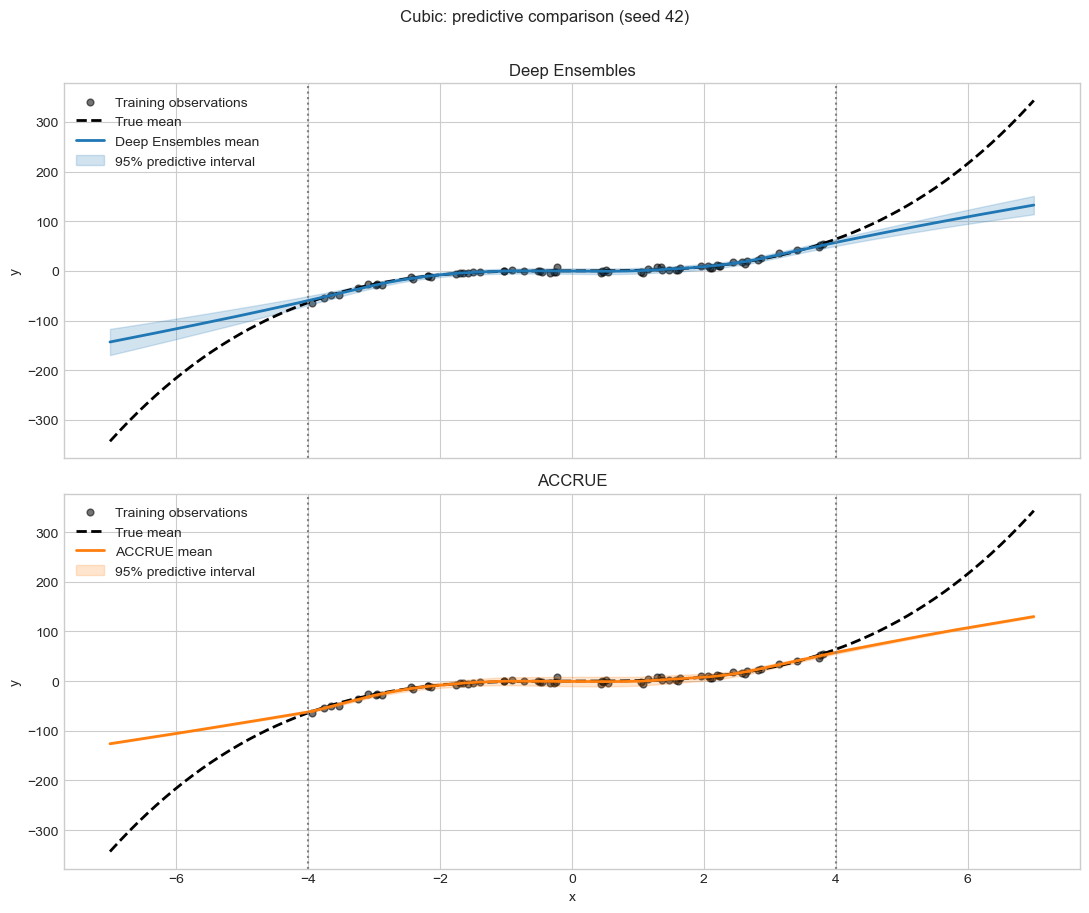

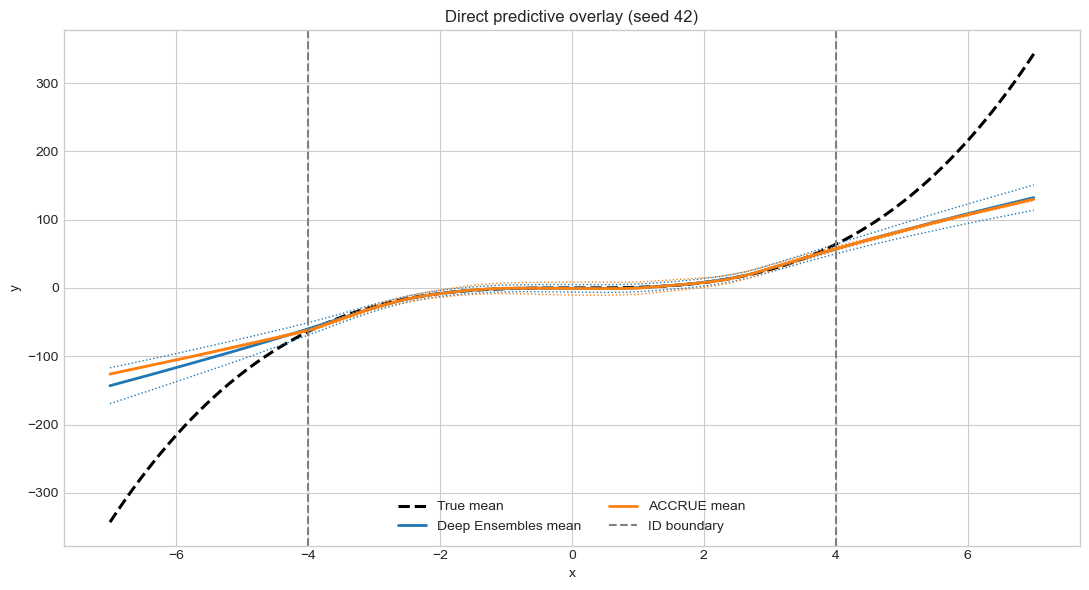

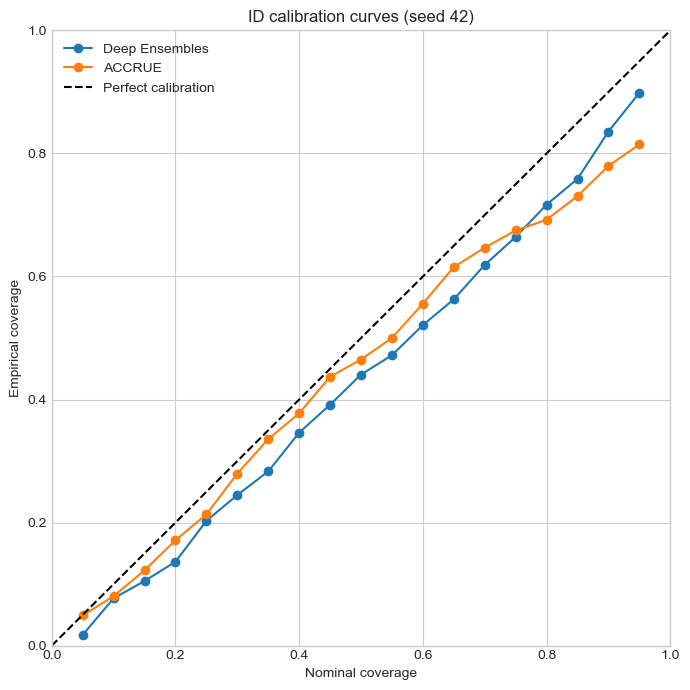

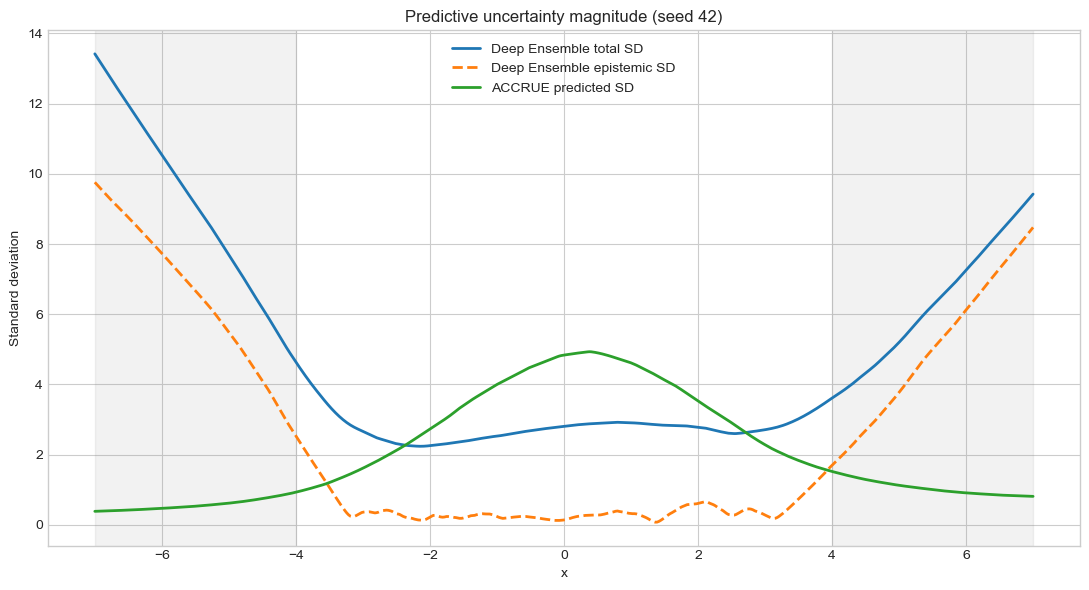

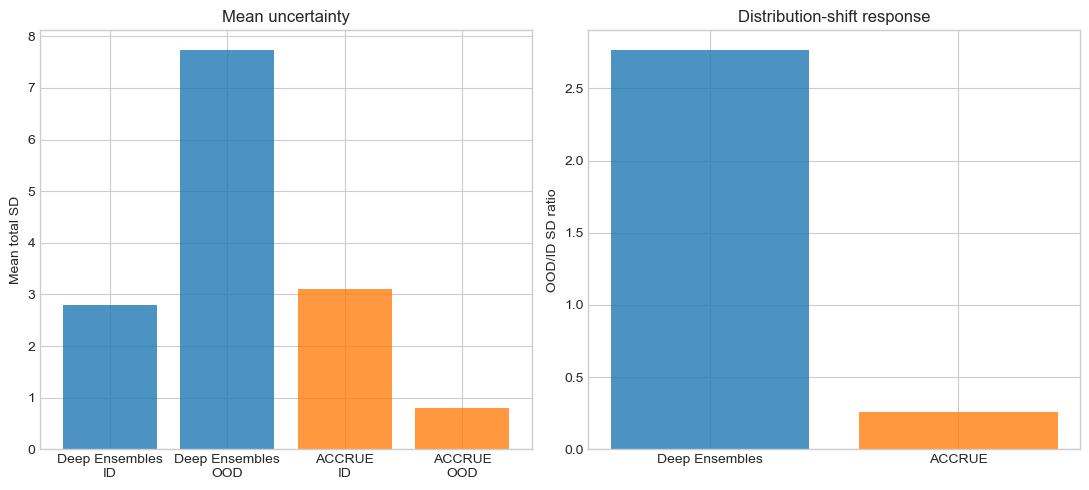

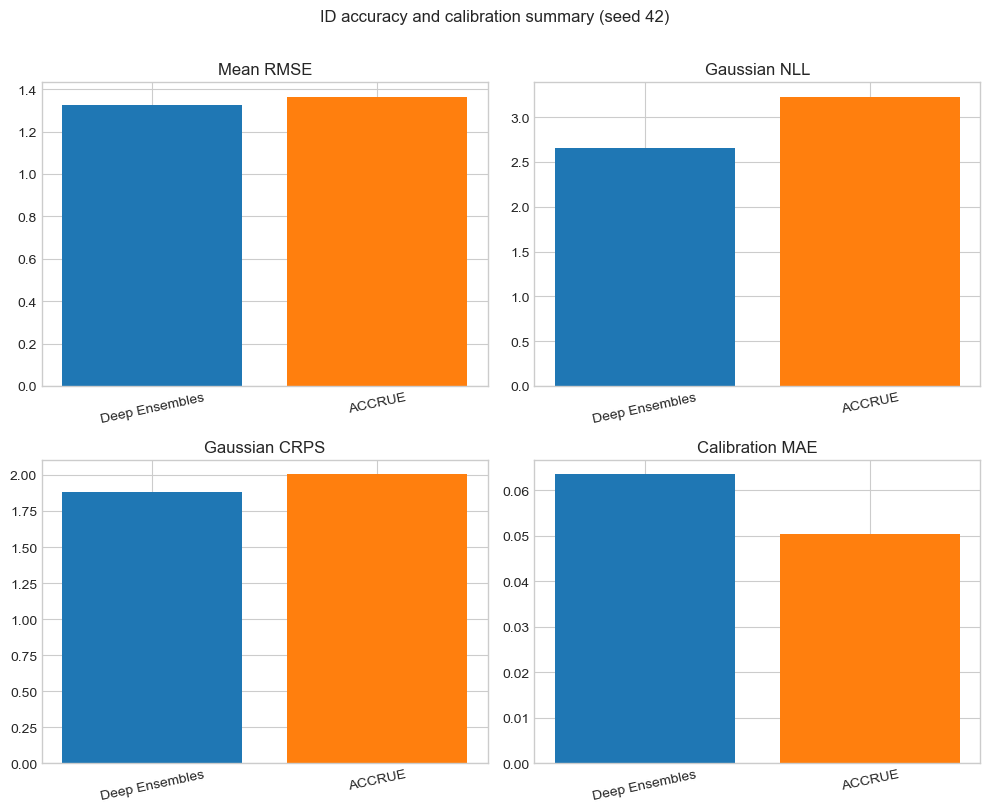

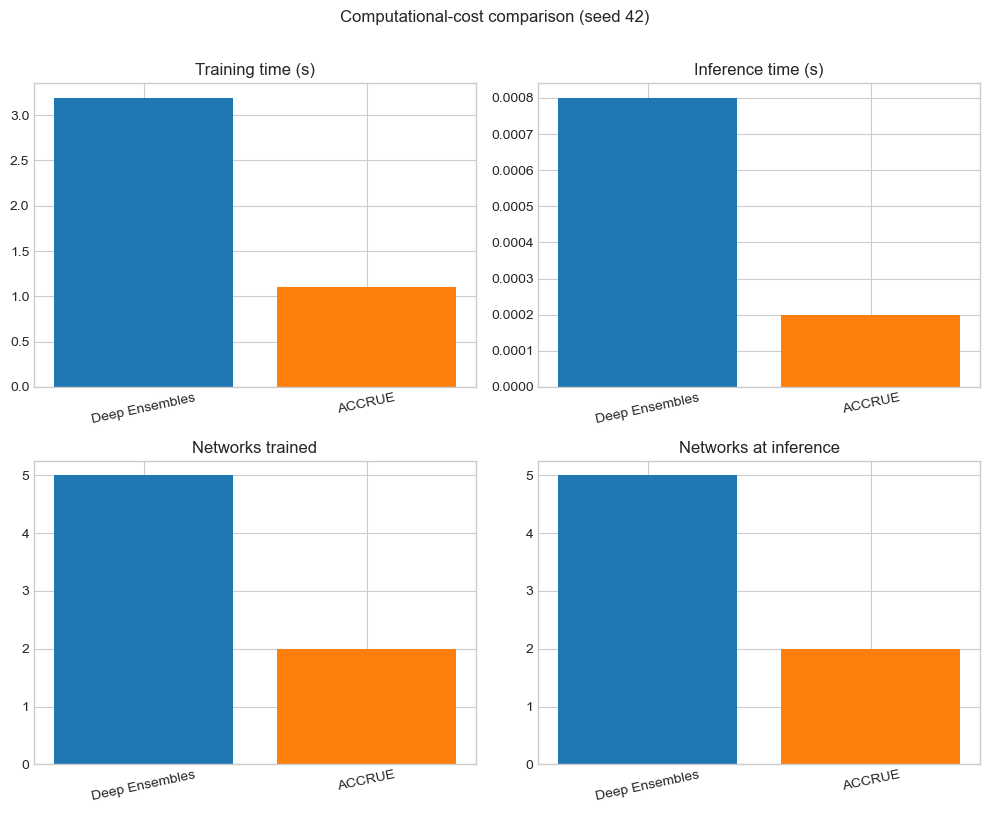

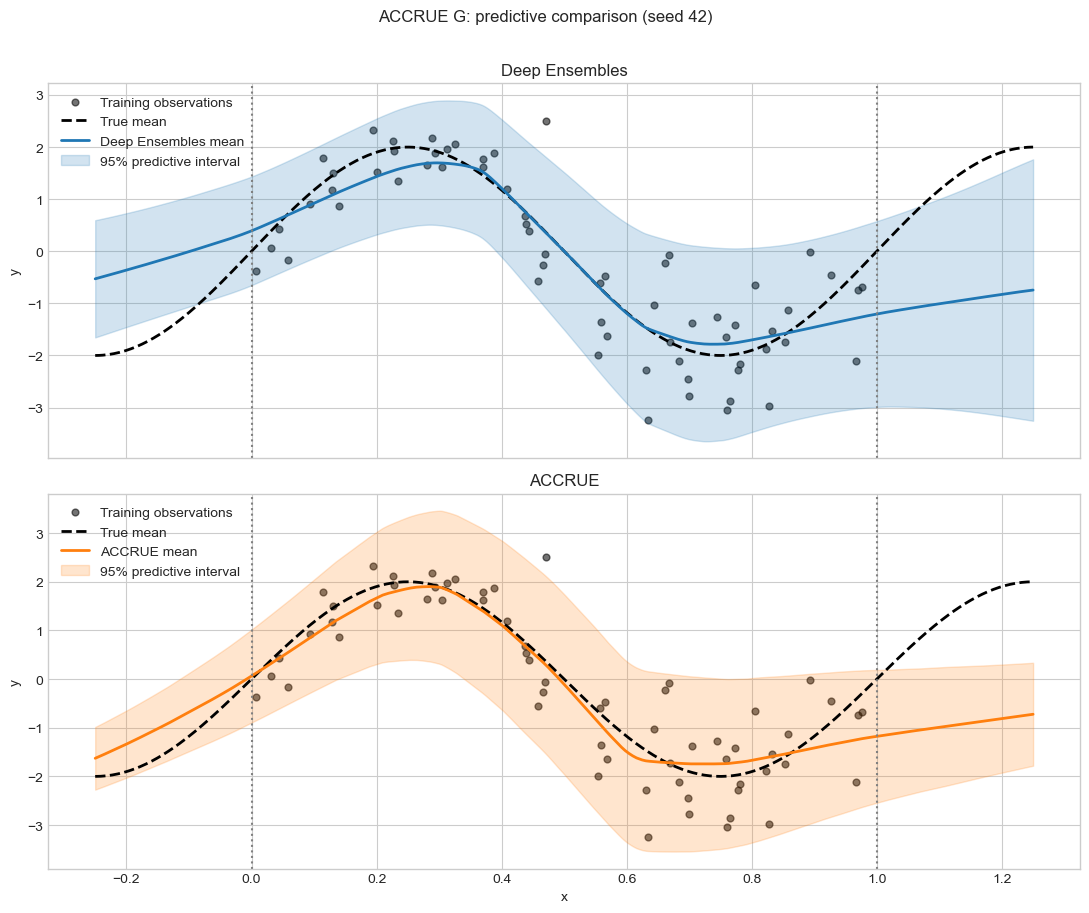

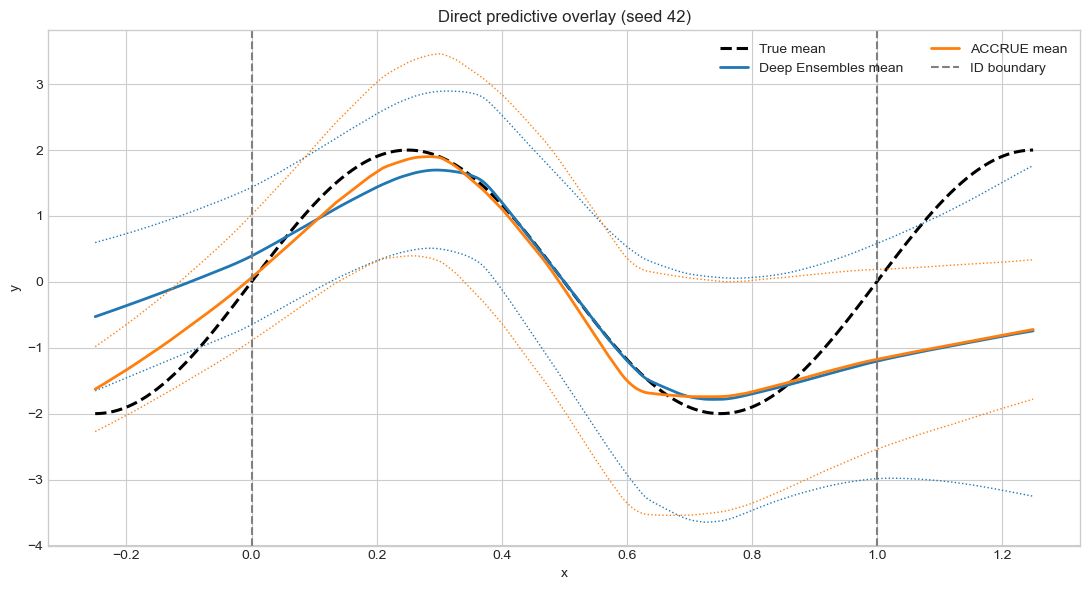

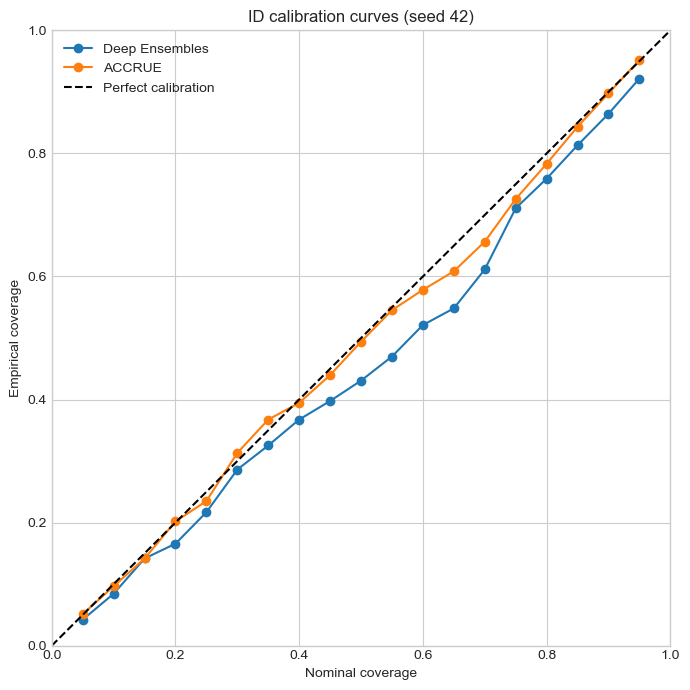

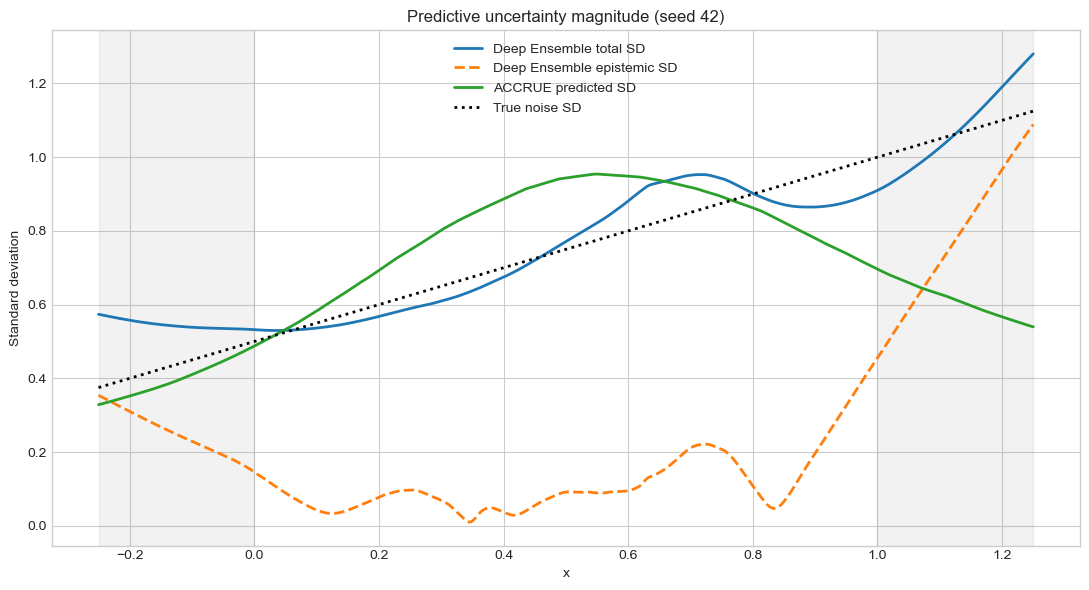

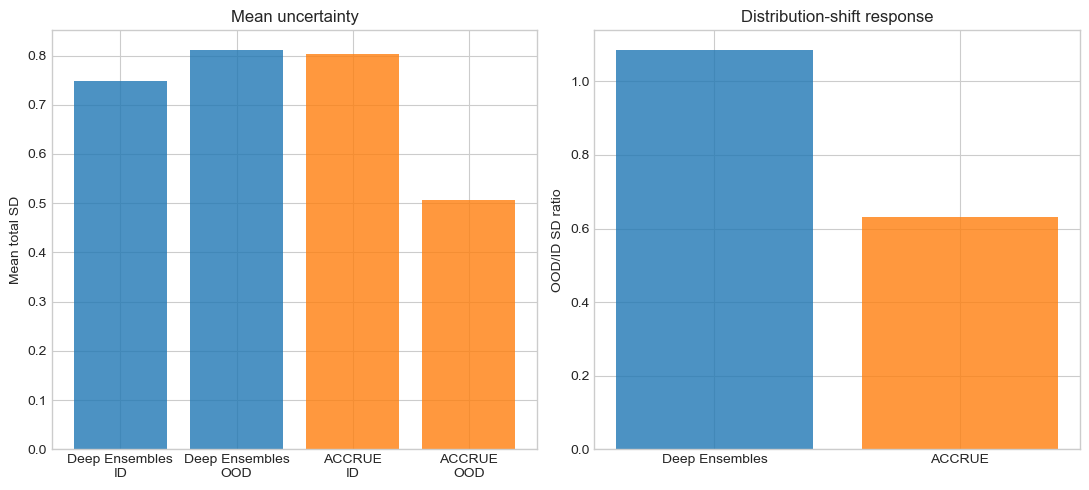

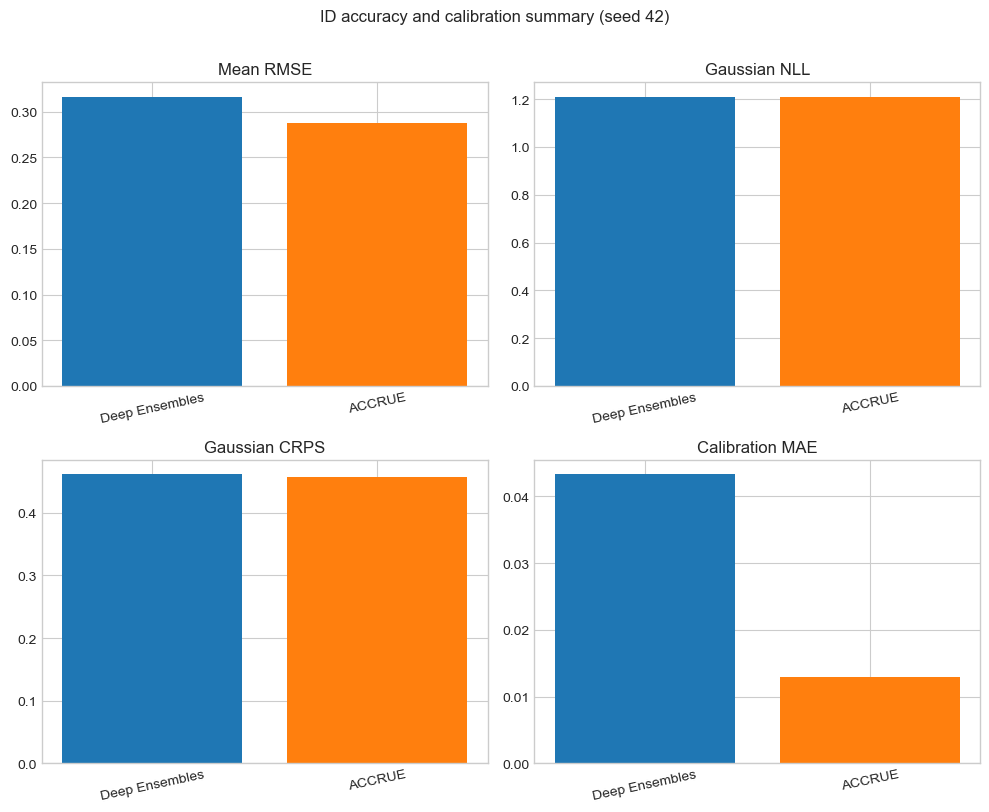

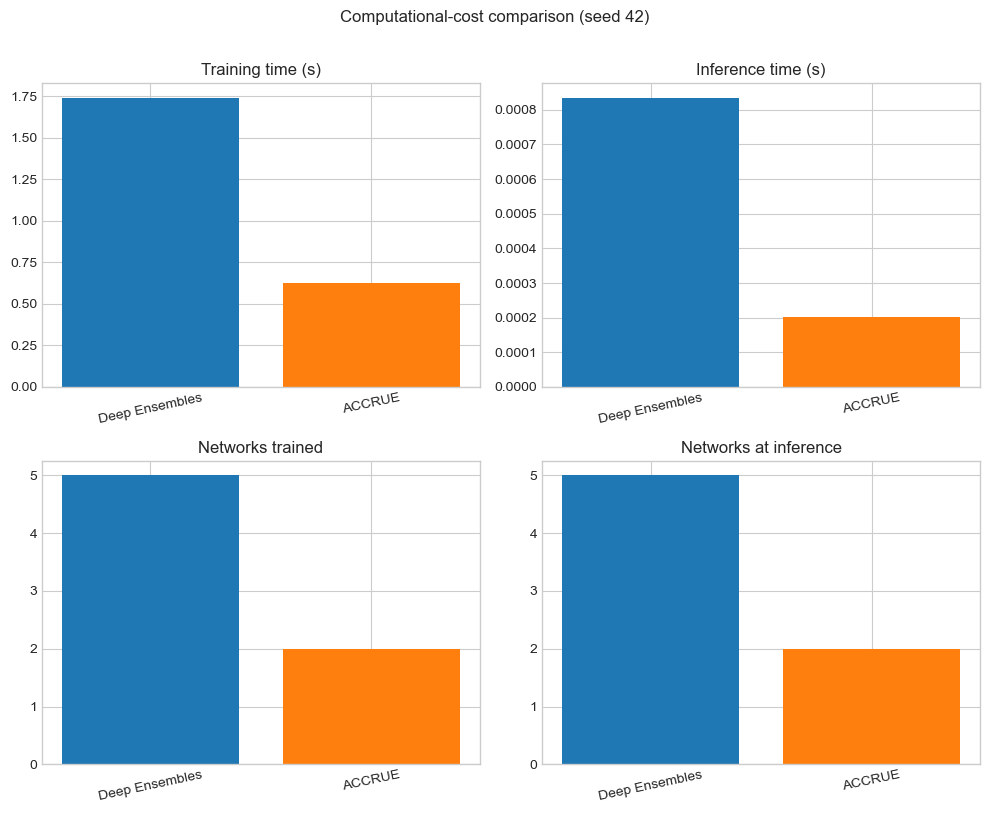

All required figures saved.


In [8]:
METHOD_COLOURS = {
    "Deep Ensembles": "tab:blue",
    "ACCRUE": "tab:orange",
}


def save_figure(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()


for dataset_name, result in seed_42_results.items():
    data = result["data"]
    predictions = result["predictions"]
    output_directory = RESULTS_ROOT / dataset_name / "figures"
    x = data["x_test"].reshape(-1)
    train_min, train_max = DATASETS[dataset_name]["train_range"]

    # 1. Predictive comparison
    fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
    for axis, method in zip(axes, ["Deep Ensembles", "ACCRUE"]):
        prediction = predictions[method]
        lower = prediction["mean"] - 1.96 * prediction["sigma"]
        upper = prediction["mean"] + 1.96 * prediction["sigma"]
        axis.scatter(
            data["x_train"],
            data["y_train"],
            s=24,
            alpha=0.55,
            color="black",
            label="Training observations",
        )
        axis.plot(x, data["y_test_true"], "k--", lw=2, label="True mean")
        axis.plot(
            x,
            prediction["mean"],
            color=METHOD_COLOURS[method],
            lw=2,
            label=f"{method} mean",
        )
        axis.fill_between(
            x,
            lower,
            upper,
            color=METHOD_COLOURS[method],
            alpha=0.2,
            label="95% predictive interval",
        )
        axis.axvline(train_min, color="grey", linestyle=":")
        axis.axvline(train_max, color="grey", linestyle=":")
        axis.set_ylabel("y")
        axis.set_title(method)
        axis.legend(loc="best")
    axes[-1].set_xlabel("x")
    fig.suptitle(
        f"{DATASETS[dataset_name]['label']}: predictive comparison (seed 42)",
        y=1.01,
    )
    save_figure(fig, output_directory / "predictive_comparison.png")

    # 2. Direct overlay
    fig, axis = plt.subplots(figsize=(11, 6))
    axis.plot(x, data["y_test_true"], "k--", lw=2.2, label="True mean")
    for method in ["Deep Ensembles", "ACCRUE"]:
        prediction = predictions[method]
        colour = METHOD_COLOURS[method]
        axis.plot(x, prediction["mean"], color=colour, lw=2, label=f"{method} mean")
        axis.plot(
            x,
            prediction["mean"] - 1.96 * prediction["sigma"],
            color=colour,
            lw=1,
            linestyle=":",
        )
        axis.plot(
            x,
            prediction["mean"] + 1.96 * prediction["sigma"],
            color=colour,
            lw=1,
            linestyle=":",
        )
    axis.axvline(train_min, color="grey", linestyle="--", label="ID boundary")
    axis.axvline(train_max, color="grey", linestyle="--")
    axis.set(xlabel="x", ylabel="y", title="Direct predictive overlay (seed 42)")
    axis.legend(ncol=2)
    save_figure(fig, output_directory / "direct_overlay.png")

    # 3. Calibration curves: ID observations
    fig, axis = plt.subplots(figsize=(7, 7))
    id_mask = data["id_mask"]
    for method in ["Deep Ensembles", "ACCRUE"]:
        prediction = predictions[method]
        levels, empirical = calibration_curve(
            data["y_test_observed"].reshape(-1)[id_mask],
            prediction["mean"][id_mask],
            prediction["sigma"][id_mask],
        )
        axis.plot(
            levels,
            empirical,
            marker="o",
            color=METHOD_COLOURS[method],
            label=method,
        )
    axis.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axis.set(
        xlabel="Nominal coverage",
        ylabel="Empirical coverage",
        title="ID calibration curves (seed 42)",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    axis.legend()
    save_figure(fig, output_directory / "calibration_curves.png")

    # 4. Uncertainty magnitude
    fig, axis = plt.subplots(figsize=(11, 6))
    deep = predictions["Deep Ensembles"]
    accrue = predictions["ACCRUE"]
    axis.plot(x, deep["sigma"], lw=2, label="Deep Ensemble total SD")
    axis.plot(
        x,
        deep["epistemic_sigma"],
        lw=2,
        linestyle="--",
        label="Deep Ensemble epistemic SD",
    )
    axis.plot(x, accrue["sigma"], lw=2, label="ACCRUE predicted SD")
    if dataset_name == "accrue_g":
        axis.plot(
            x,
            data["sigma_test_true"],
            "k:",
            lw=2,
            label="True noise SD",
        )
    axis.axvspan(x.min(), train_min, color="grey", alpha=0.1)
    axis.axvspan(train_max, x.max(), color="grey", alpha=0.1)
    axis.set(
        xlabel="x",
        ylabel="Standard deviation",
        title="Predictive uncertainty magnitude (seed 42)",
    )
    axis.legend()
    save_figure(fig, output_directory / "uncertainty_magnitude.png")

    # 5. ID/OOD uncertainty
    uncertainty_rows = []
    for method, prediction in predictions.items():
        id_sd = prediction["sigma"][data["id_mask"]].mean()
        ood_sd = prediction["sigma"][data["ood_mask"]].mean()
        uncertainty_rows.extend([
            {"method": method, "quantity": "Mean ID SD", "value": id_sd},
            {"method": method, "quantity": "Mean OOD SD", "value": ood_sd},
            {
                "method": method,
                "quantity": "OOD/ID ratio",
                "value": ood_sd / max(id_sd, EPS),
            },
        ])
    uncertainty_plot_data = pd.DataFrame(uncertainty_rows)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for method in ["Deep Ensembles", "ACCRUE"]:
        subset = uncertainty_plot_data[
            uncertainty_plot_data["method"] == method
        ]
        axes[0].bar(
            [f"{method}\nID", f"{method}\nOOD"],
            subset.iloc[:2]["value"],
            color=METHOD_COLOURS[method],
            alpha=0.8,
        )
        axes[1].bar(
            method,
            subset.iloc[2]["value"],
            color=METHOD_COLOURS[method],
            alpha=0.8,
        )
    axes[0].set(title="Mean uncertainty", ylabel="Mean total SD")
    axes[1].set(title="Distribution-shift response", ylabel="OOD/ID SD ratio")
    save_figure(fig, output_directory / "id_ood_uncertainty.png")

    # 6. Accuracy and calibration summary: seed 42, ID
    seed_metrics = all_metrics[
        (all_metrics["dataset"] == dataset_name)
        & (all_metrics["seed"] == 42)
        & (all_metrics["region"] == "ID")
    ].set_index("method")
    plot_metrics = [
        ("mean_rmse", "Mean RMSE"),
        ("gaussian_nll", "Gaussian NLL"),
        ("gaussian_crps", "Gaussian CRPS"),
        ("calibration_mae", "Calibration MAE"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for axis, (metric, label) in zip(axes.ravel(), plot_metrics):
        methods = ["Deep Ensembles", "ACCRUE"]
        axis.bar(
            methods,
            seed_metrics.loc[methods, metric],
            color=[METHOD_COLOURS[method] for method in methods],
        )
        axis.set_title(label)
        axis.tick_params(axis="x", rotation=12)
    fig.suptitle("ID accuracy and calibration summary (seed 42)", y=1.01)
    save_figure(fig, output_directory / "accuracy_calibration_summary.png")

    # 7. Computational cost
    full_seed_metrics = all_metrics[
        (all_metrics["dataset"] == dataset_name)
        & (all_metrics["seed"] == 42)
        & (all_metrics["region"] == "Full")
    ].set_index("method")
    cost_metrics = [
        ("training_time_seconds", "Training time (s)"),
        ("inference_time_seconds", "Inference time (s)"),
        ("trained_networks", "Networks trained"),
        ("inference_networks", "Networks at inference"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for axis, (metric, label) in zip(axes.ravel(), cost_metrics):
        methods = ["Deep Ensembles", "ACCRUE"]
        axis.bar(
            methods,
            full_seed_metrics.loc[methods, metric],
            color=[METHOD_COLOURS[method] for method in methods],
        )
        axis.set_title(label)
        axis.tick_params(axis="x", rotation=12)
    fig.suptitle("Computational-cost comparison (seed 42)", y=1.01)
    save_figure(fig, output_directory / "computational_cost.png")

print("All required figures saved.")



## Result-guided conclusion

The statements below are generated from the repeated ID results. They are
deliberately separated by evaluation dimension; a method is not declared
universally superior from one metric alone.



In [9]:
def lower_is_better_winner(table, metric):
    means = table.groupby("method")[metric].mean()
    return means.idxmin(), means


def coverage_winner(table, metric, target):
    means = table.groupby("method")[metric].mean()
    return (means - target).abs().idxmin(), means


for dataset_name, dataset_specification in DATASETS.items():
    id_results = all_metrics[
        (all_metrics["dataset"] == dataset_name)
        & (all_metrics["region"] == "ID")
    ]
    ood_results = all_metrics[
        (all_metrics["dataset"] == dataset_name)
        & (all_metrics["region"] == "Full")
    ]
    accuracy_winner, rmse_values = lower_is_better_winner(
        id_results, "mean_rmse"
    )
    calibration_winner, calibration_values = lower_is_better_winner(
        id_results, "calibration_mae"
    )
    crps_winner, crps_values = lower_is_better_winner(
        id_results, "gaussian_crps"
    )
    coverage_95_winner, coverage_values = coverage_winner(
        id_results, "coverage_95", 0.95
    )
    ratio_values = (
        ood_results.groupby("method")["ood_id_total_sd_ratio"].mean()
    )

    print(f"\n{dataset_specification['label']}")
    print("-" * len(dataset_specification["label"]))
    print(
        f"Mean accuracy: {accuracy_winner} had the lower mean ID RMSE "
        f"({rmse_values[accuracy_winner]:.4f})."
    )
    print(
        f"Calibration: {calibration_winner} had the lower mean ID "
        f"calibration MAE ({calibration_values[calibration_winner]:.4f})."
    )
    print(
        f"Probabilistic accuracy: {crps_winner} had the lower mean ID CRPS "
        f"({crps_values[crps_winner]:.4f})."
    )
    print(
        f"95% coverage: {coverage_95_winner} was closer to the nominal 0.95 "
        f"coverage (empirical {coverage_values[coverage_95_winner]:.4f})."
    )
    print(
        "Mean OOD/ID total-SD ratios — "
        + ", ".join(
            f"{method}: {value:.3f}"
            for method, value in ratio_values.items()
        )
        + "."
    )

print(
    "\nInterpretation note: Deep Ensembles expose a separate epistemic component "
    "through member disagreement. ACCRUE's predicted sigma is a combined "
    "residual-based uncertainty around its fixed mean model; epistemic "
    "uncertainty is therefore reported as not separately available, not zero."
)




Cubic
-----
Mean accuracy: Deep Ensembles had the lower mean ID RMSE (1.5408).
Calibration: Deep Ensembles had the lower mean ID calibration MAE (0.0529).
Probabilistic accuracy: Deep Ensembles had the lower mean ID CRPS (1.9337).
95% coverage: Deep Ensembles was closer to the nominal 0.95 coverage (empirical 0.8965).
Mean OOD/ID total-SD ratios — ACCRUE: 0.775, Deep Ensembles: 1.858.

ACCRUE G
--------
Mean accuracy: Deep Ensembles had the lower mean ID RMSE (0.3285).
Calibration: Deep Ensembles had the lower mean ID calibration MAE (0.0356).
Probabilistic accuracy: Deep Ensembles had the lower mean ID CRPS (0.4620).
95% coverage: Deep Ensembles was closer to the nominal 0.95 coverage (empirical 0.9175).
Mean OOD/ID total-SD ratios — ACCRUE: 0.744, Deep Ensembles: 1.086.

Interpretation note: Deep Ensembles expose a separate epistemic component through member disagreement. ACCRUE's predicted sigma is a combined residual-based uncertainty around its fixed mean model; epistemic uncerta

## Final interpretation checklist

Use the saved repeated-run tables and figures when writing the dissertation:

1. Compare mean prediction accuracy using ID mean RMSE.
2. Compare probabilistic quality using Gaussian NLL and CRPS.
3. Compare calibration using calibration MAE and 68%/95% coverage.
4. Compare sharpness only together with coverage.
5. Compare OOD response using total-SD ratios and, for Deep Ensembles,
   epistemic-SD ratios.
6. For the ACCRUE G dataset, compare recovery of the known noise with sigma
   RMSE. Deep Ensembles use aleatoric SD for this comparison.
7. Discuss the computational trade-off: five inference networks for Deep
   Ensembles versus the ACCRUE mean and uncertainty networks.
8. Do not interpret ACCRUE's missing epistemic decomposition as zero
   epistemic uncertainty.

Saved outputs are under:

- `results/comparison/cubic/`
- `results/comparison/accrue_g/`
- `results/comparison/all_per_seed_metrics.csv`
- `results/comparison/paired_differences.csv`
